# Objective

This notebook demonstrates how SQL queries and Python can be combined to analyze AdventureWorks sales data.

The analysis focuses on:

1. Sales performance over time
2. Product and category performance
3. Customer contribution
4. Order quantities and operational performance

# Code

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc

In [2]:
conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=localhost;'
    'DATABASE=AdventureWorks2025;'
    'Trusted_Connection=yes;'
)

In [3]:
query = """
    SELECT SalesOrderID, OrderDate, DueDate, ShipDate, CustomerID, SubTotal, TaxAmt, Freight, TotalDue FROM Sales.SalesOrderHeader
    """
orders = pd.read_sql(query, conn)

C:\Users\micro\AppData\Local\Temp\ipykernel_25028\581686768.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql(query, conn)


In [4]:
query = """
    SELECT ProductID, pp.Name, Color, StandardCost, ListPrice, ps.Name AS SubCategory, pc.Name AS Category FROM Production.Product pp
    LEFT JOIN Production.ProductSubcategory ps
    ON pp.ProductSubcategoryID = ps.ProductSubcategoryID
    LEFT JOIN Production.ProductCategory pc
    ON ps.ProductCategoryID = pc.ProductCategoryID
    """
products = pd.read_sql(query, conn)

C:\Users\micro\AppData\Local\Temp\ipykernel_25028\923450738.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  products = pd.read_sql(query, conn)


In [5]:
query = """
    SELECT SalesOrderID, SalesOrderDetailID, OrderQty, ProductID, UnitPrice, UnitPriceDiscount, LineTotal FROM Sales.SalesOrderDetail
    """
order_details = pd.read_sql(query, conn)

C:\Users\micro\AppData\Local\Temp\ipykernel_25028\2558159846.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_details = pd.read_sql(query, conn)


In [6]:
orders.head(5)

,SalesOrderID,OrderDate,DueDate,ShipDate,CustomerID,SubTotal,TaxAmt,Freight,TotalDue
0,43659,2022-05-30,2022-06-11,2022-06-06,29825,20565.6206,1971.5149,616.0984,23153.2339
1,43660,2022-05-30,2022-06-11,2022-06-06,29672,1294.2529,124.2483,38.8276,1457.3288
2,43661,2022-05-30,2022-06-11,2022-06-06,29734,32726.4786,3153.7696,985.5530,36865.8012
3,43662,2022-05-30,2022-06-11,2022-06-06,29994,28832.5289,2775.1646,867.2389,32474.9324
4,43663,2022-05-30,2022-06-11,2022-06-06,29565,419.4589,40.2681,12.5838,472.3108


In [7]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 31465 entries, 0 to 31464
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   SalesOrderID  31465 non-null  int64         
 1   OrderDate     31465 non-null  datetime64[us]
 2   DueDate       31465 non-null  datetime64[us]
 3   ShipDate      31465 non-null  datetime64[us]
 4   CustomerID    31465 non-null  int64         
 5   SubTotal      31465 non-null  float64       
 6   TaxAmt        31465 non-null  float64       
 7   Freight       31465 non-null  float64       
 8   TotalDue      31465 non-null  float64       
dtypes: datetime64[us](3), float64(4), int64(2)
memory usage: 2.2 MB


In [8]:
orders.isna().sum()

SalesOrderID    0
OrderDate       0
DueDate         0
ShipDate        0
CustomerID      0
SubTotal        0
TaxAmt          0
Freight         0
TotalDue        0
dtype: int64

In [9]:
products.head(5)

,ProductID,Name,Color,StandardCost,ListPrice,SubCategory,Category
0,1,Adjustable Race,NaN,0.0,0.0,NaN,NaN
1,2,Bearing Ball,NaN,0.0,0.0,NaN,NaN
2,3,BB Ball Bearing,NaN,0.0,0.0,NaN,NaN
3,4,Headset Ball Bearings,NaN,0.0,0.0,NaN,NaN
4,316,Blade,NaN,0.0,0.0,NaN,NaN


In [10]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ProductID     504 non-null    int64  
 1   Name          504 non-null    str    
 2   Color         256 non-null    str    
 3   StandardCost  504 non-null    float64
 4   ListPrice     504 non-null    float64
 5   SubCategory   295 non-null    str    
 6   Category      295 non-null    str    
dtypes: float64(2), int64(1), str(4)
memory usage: 27.7 KB


In [11]:
products.isna().sum()

ProductID         0
Name              0
Color           248
StandardCost      0
ListPrice         0
SubCategory     209
Category        209
dtype: int64

In [12]:
order_details.head(5)

,SalesOrderID,SalesOrderDetailID,OrderQty,ProductID,UnitPrice,UnitPriceDiscount,LineTotal
0,43659,1,1,776,2024.994,0.0,2024.994
1,43659,2,3,777,2024.994,0.0,6074.982
2,43659,3,1,778,2024.994,0.0,2024.994
3,43659,4,1,771,2039.994,0.0,2039.994
4,43659,5,1,772,2039.994,0.0,2039.994


In [13]:
order_details.info()

<class 'pandas.DataFrame'>
RangeIndex: 121317 entries, 0 to 121316
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   SalesOrderID        121317 non-null  int64  
 1   SalesOrderDetailID  121317 non-null  int64  
 2   OrderQty            121317 non-null  int64  
 3   ProductID           121317 non-null  int64  
 4   UnitPrice           121317 non-null  float64
 5   UnitPriceDiscount   121317 non-null  float64
 6   LineTotal           121317 non-null  float64
dtypes: float64(3), int64(4)
memory usage: 6.5 MB


In [14]:
order_details.isna().sum()

SalesOrderID          0
SalesOrderDetailID    0
OrderQty              0
ProductID             0
UnitPrice             0
UnitPriceDiscount     0
LineTotal             0
dtype: int64

In [37]:
products['TotalValue'] = products['ProductID'].map(order_details.groupby('ProductID')['LineTotal'].sum())

In [17]:
orders['TotalQty'] = orders['SalesOrderID'].map(order_details.groupby('SalesOrderID')['OrderQty'].sum())

In [18]:
orders.describe()

,SalesOrderID,OrderDate,DueDate,ShipDate,CustomerID,SubTotal,TaxAmt,Freight,TotalDue,TotalQty
count,31465.000000,31465,31465,31465,31465.000000,31465.000000,31465.000000,31465.000000,31465.000000,31465.000000
mean,59391.000000,2024-08-20 11:43:49.321468,2024-09-01 11:44:14.034641,2024-08-27 11:44:14.034641,20170.175687,3491.065673,323.755743,101.173693,3915.995109,8.737137
min,43659.000000,2022-05-30 00:00:00,2022-06-11 00:00:00,2022-06-06 00:00:00,11000.000000,1.374000,0.109900,0.034400,1.518300,1.000000
25%,51525.000000,2024-06-19 00:00:00,2024-07-01 00:00:00,2024-06-26 00:00:00,14432.000000,56.970000,4.557600,1.424300,62.951900,1.000000
50%,59391.000000,2024-11-02 00:00:00,2024-11-14 00:00:00,2024-11-09 00:00:00,19452.000000,782.990000,62.639200,19.574800,865.204000,2.000000
75%,67257.000000,2025-02-27 00:00:00,2025-03-12 00:00:00,2025-03-07 00:00:00,25994.000000,2366.960000,189.597600,59.249300,2615.490800,3.000000
max,75123.000000,2025-06-29 00:00:00,2025-07-11 00:00:00,2025-07-06 00:00:00,30118.000000,163930.394300,17948.518600,5608.912100,187487.825000,499.000000
std,9083.307446,NaN,NaN,NaN,6261.728960,11093.452536,1085.054180,339.079427,12515.462713,31.478986


In [19]:
products.describe()

,ProductID,StandardCost,ListPrice,TotalValue
count,504.000000,504.000000,504.000000,0.0
mean,673.039683,258.602961,438.666250,NaN
std,229.373142,461.632808,773.602843,NaN
min,1.000000,0.000000,0.000000,NaN
25%,447.750000,0.000000,0.000000,NaN
50%,747.500000,23.372200,49.990000,NaN
75%,873.250000,317.075825,564.990000,NaN
max,999.000000,2171.294200,3578.270000,NaN


In [20]:
order_details.describe()

,SalesOrderID,SalesOrderDetailID,OrderQty,ProductID,UnitPrice,UnitPriceDiscount,LineTotal
count,121317.000000,121317.000000,121317.000000,121317.000000,121317.000000,121317.000000,121317.000000
mean,57827.363782,60659.000000,2.266080,841.680836,465.093496,0.002826,905.449207
std,9009.147902,35021.345641,2.491323,86.452124,751.885081,0.024811,1693.417389
min,43659.000000,1.000000,1.000000,707.000000,1.328200,0.000000,1.374000
25%,49884.000000,30330.000000,1.000000,768.000000,21.490000,0.000000,24.990000
50%,57029.000000,60659.000000,1.000000,863.000000,49.990000,0.000000,134.982000
75%,65490.000000,90988.000000,3.000000,921.000000,602.346000,0.000000,1120.490000
max,75123.000000,121317.000000,44.000000,999.000000,3578.270000,0.400000,27893.619000


In [21]:
len(orders)

31465

There are 31,465 orders in total.

In [22]:
monthly_sales = (
    orders
    .groupby(orders["OrderDate"].dt.to_period("M"))["TotalDue"]
    .sum()
)

monthly_sales.index = monthly_sales.index.to_timestamp()

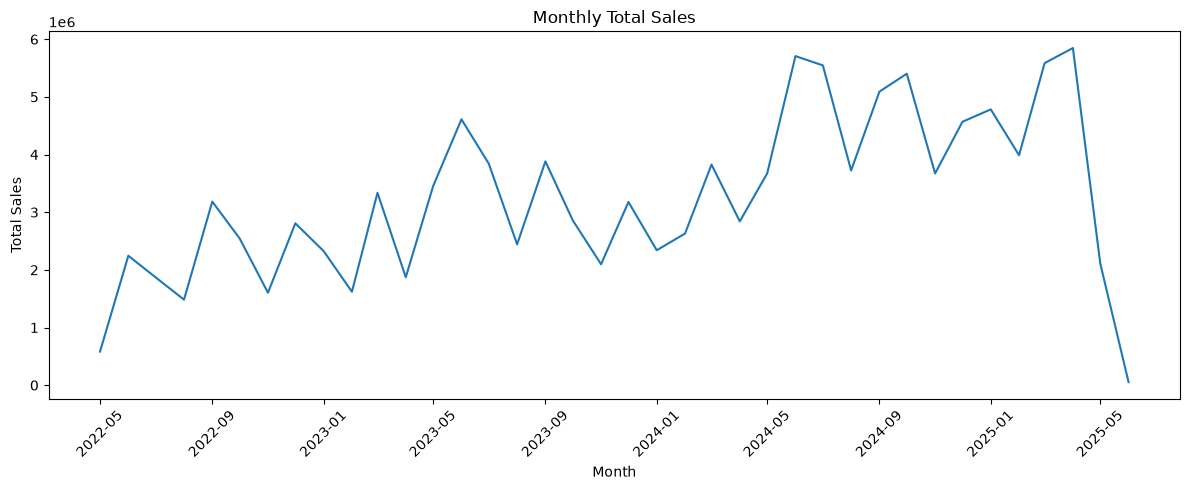

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

In [24]:
len(products)

504

In [42]:
order_details['ProductID'].nunique()

266

In [43]:
order_details['ProductID'].nunique() / len(products)

0.5277777777777778

The data contains 504 unique products, though only ~52.8% (266) are involved in orders.

In [72]:
top_products_by_sales = (
    products
    .nlargest(10, 'TotalValue')
    .set_index('Name')['TotalValue']
    .sort_values(ascending=False)
)

In [68]:
products[products['Name'].isin(top_products_by_sales.index)]

,ProductID,Name,Color,StandardCost,ListPrice,SubCategory,Category,TotalValue
257,753,"Road-150 Red, 56",Red,2171.2942,3578.27,Road Bikes,Bikes,1.847819e+06
283,779,"Mountain-200 Silver, 38",Silver,1265.6195,2319.99,Mountain Bikes,Bikes,3.693678e+06
284,780,"Mountain-200 Silver, 42",Silver,1265.6195,2319.99,Mountain Bikes,Bikes,3.438479e+06
285,781,"Mountain-200 Silver, 46",Silver,1265.6195,2319.99,Mountain Bikes,Bikes,3.434257e+06
286,782,"Mountain-200 Black, 38",Black,1251.9813,2294.99,Mountain Bikes,Bikes,4.400593e+06
287,783,"Mountain-200 Black, 42",Black,1251.9813,2294.99,Mountain Bikes,Bikes,4.009495e+06
288,784,"Mountain-200 Black, 46",Black,1251.9813,2294.99,Mountain Bikes,Bikes,3.309673e+06
297,793,"Road-250 Black, 44",Black,1554.9479,2443.35,Road Bikes,Bikes,2.516857e+06
298,794,"Road-250 Black, 48",Black,1554.9479,2443.35,Road Bikes,Bikes,2.347656e+06
299,795,"Road-250 Black, 52",Black,1554.9479,2443.35,Road Bikes,Bikes,2.012448e+06


Text(0.5, 1.0, 'Log-transformed Product Sales Value Distribution')

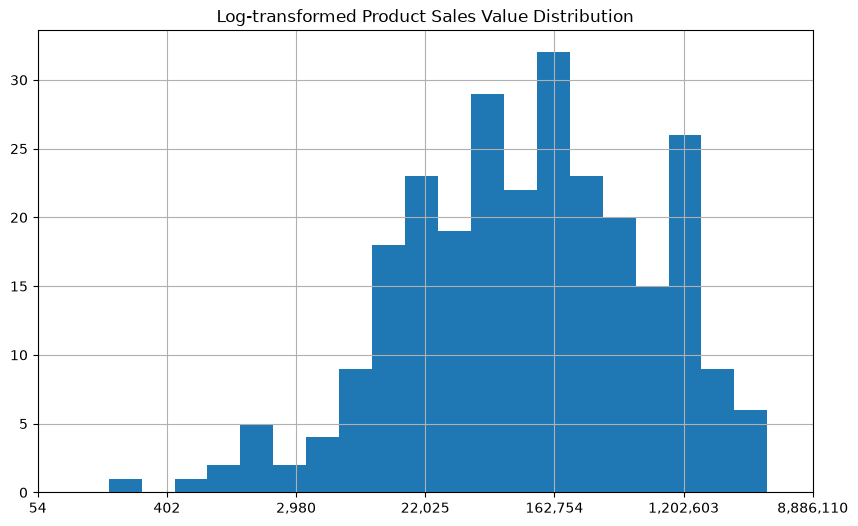

In [69]:
plt.figure(figsize=(10, 6))
ax = np.log1p(products['TotalValue']).hist(bins=20)
ticks = ax.get_xticks()
ax.set_xticks(ticks)
ax.set_xticklabels([
    f'{np.expm1(tick):,.0f}' for tick in ticks
])
plt.title("Log-transformed Product Sales Value Distribution")

<Axes: title={'center': 'Top 10 Products by Sales Value'}, ylabel='Name'>

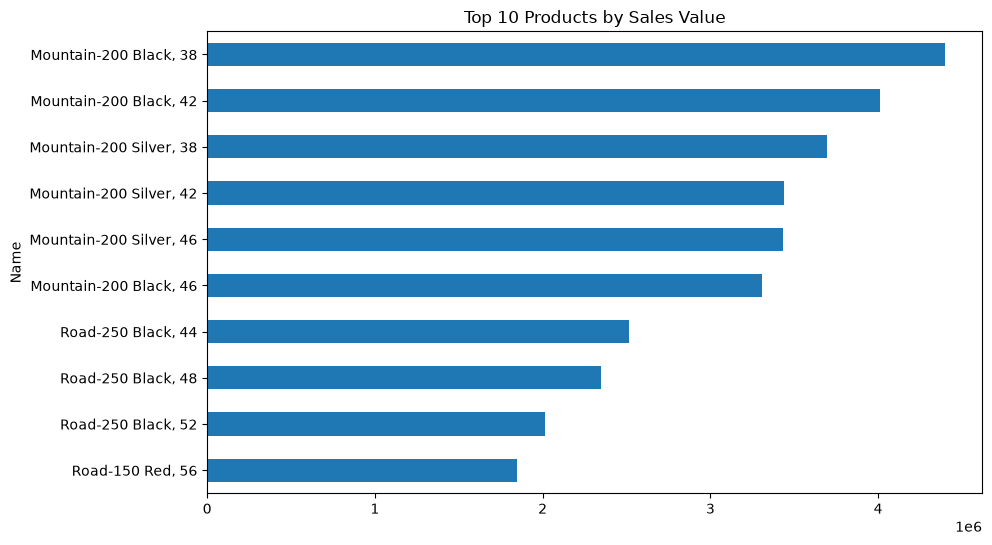

In [70]:
top_products_by_sales.plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Products by Sales Value"
)

Text(0.5, 1.0, 'Categories Counts Pie Chart')

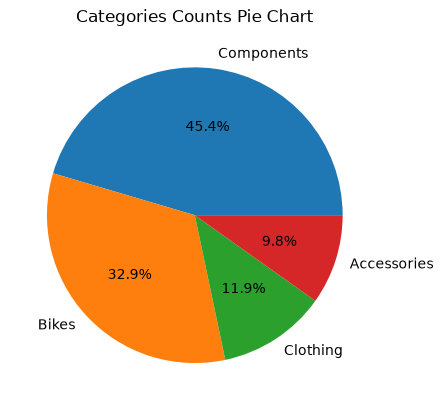

In [ ]:
plt.pie(products['Category'].value_counts(), labels=products['Category'].value_counts().index, autopct='%1.1f%%')
plt.title('Categories Counts Pie Chart')

Text(0.5, 1.0, 'Categories Sales Pie Chart')

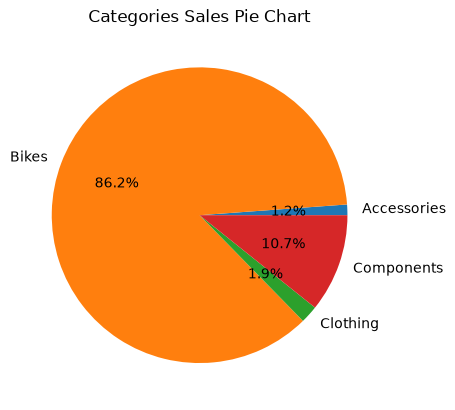

In [ ]:
plt.pie(products.groupby('Category')['TotalValue'].sum(), labels=products.groupby('Category')['TotalValue'].sum().index, autopct='%1.1f%%')
plt.title('Categories Sales Pie Chart')

In [27]:
orders['CustomerID'].nunique()

19119

The data contains 19,119 unique customers.

In [28]:
repeat_purchase_rate = (orders.groupby('CustomerID')['SalesOrderID'].count() >= 2).sum() / orders['CustomerID'].nunique()
repeat_purchase_rate

np.float64(0.3907108112348972)

Repeat-purchase rate is 39%.

In [29]:
customer_sales = (
    orders
    .groupby("CustomerID")["TotalDue"]
    .sum()
    .sort_values(ascending=False)
)

customer_sales.head(10)

CustomerID
29818    989184.0820
29715    961675.8596
29722    954021.9235
30117    919801.8188
29614    901346.8560
29639    887090.4106
29701    841866.5522
29617    834475.9271
29994    824331.7682
29646    820383.5466
Name: TotalDue, dtype: float64

Text(0.5, 1.0, 'Log-transformed Customers Sales Value Distribution')

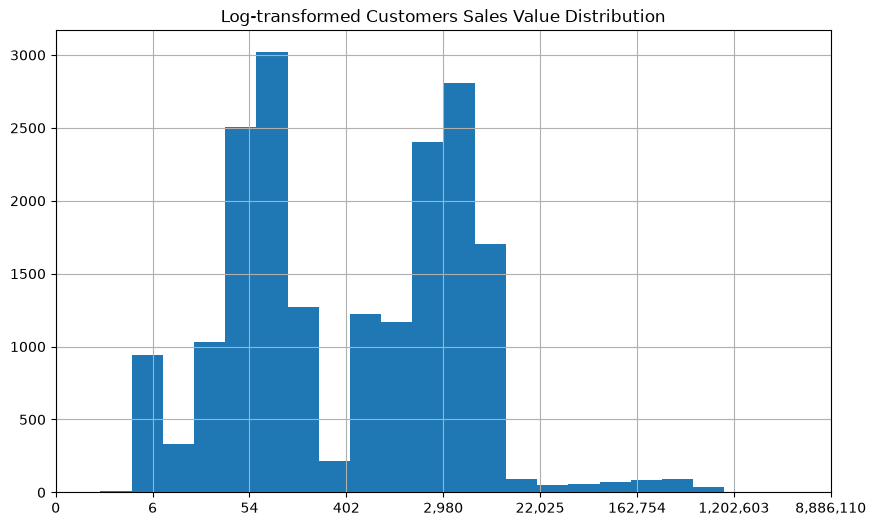

In [30]:
plt.figure(figsize=(10, 6))
ax = np.log1p(customer_sales).hist(bins=20)
ticks = ax.get_xticks()
ax.set_xticks(ticks)
ax.set_xticklabels([
    f'{np.expm1(tick):,.0f}' for tick in ticks
])
plt.title("Log-transformed Customers Sales Value Distribution")

There seems to be 2 peaks in customer sales.

Text(0, 0.5, 'Frequency')

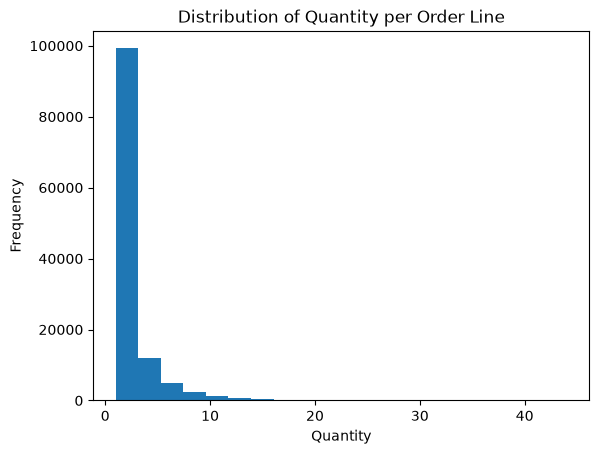

In [ ]:
plt.hist(order_details['OrderQty'], bins=20)
plt.title('Distribution of Quantity per Order Line')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

Text(0.5, 1.0, 'Log-transformed Order Quantity vs. Order Value')

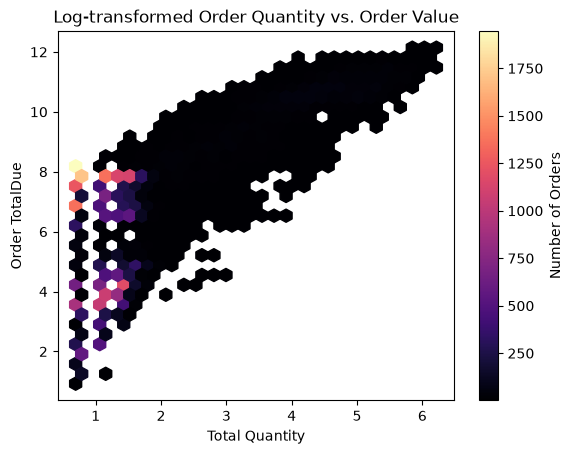

In [ ]:
plt.hexbin(
    np.log1p(orders['TotalQty']),
    np.log1p(orders['TotalDue']),
    gridsize=30,
    mincnt=1,
    cmap='magma'
)

plt.colorbar(label='Number of Orders')
plt.xlabel('Total Quantity')
plt.ylabel('Order TotalDue')
plt.title('Log-transformed Order Quantity vs. Order Value')